# 01 · Exploración de Landing

**Proyecto:** Cloud Provider Analytics · Minería de Datos II · ISTEA 2C 2026
**Objetivo:** evidencia del punto 3 de la Entrega 1 (inventario y perfil de las fuentes). Lee los archivos de `data/datalake/landing/` **sin modificarlos** y mide grano, tipos, nulos, calidad e integridad.

> Para la exploración se usa pandas por simplicidad. El pipeline (entrega 2) se implementa en PySpark con los mismos chequeos.

In [1]:
from pathlib import Path
import json, glob
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
LANDING = Path('../data/datalake/landing')
EVIDENCE = Path('../evidence'); EVIDENCE.mkdir(exist_ok=True)
assert LANDING.exists(), 'Copiar el dataset en data/datalake/landing (ver data/README.md)'

## 1. Carga
Los CSV se leen como texto (`dtype=str`) para detectar los tipos ambiguos antes de castear.

In [2]:
CSV = ['customers_orgs','users','resources','support_tickets','marketing_touches','nps_surveys','billing_monthly']
dfs = {n: pd.read_csv(LANDING/f'{n}.csv', dtype=str, keep_default_na=False, na_values=['']) for n in CSV}

rows, files = [], sorted(glob.glob(str(LANDING/'usage_events_stream'/'*.jsonl')))
for i, f in enumerate(files):
    with open(f) as fh:
        for line in fh:
            d = json.loads(line); d['_file_idx'] = i; rows.append(d)
ev = pd.DataFrame(rows)
ev['ts'] = pd.to_datetime(ev['timestamp'], utc=True)
print(f'{len(files)} archivos JSONL · {len(ev):,} eventos')

120 archivos JSONL · 43,200 eventos


## 2. Inventario

In [3]:
PK = {'customers_orgs':'org_id','users':'user_id','resources':'resource_id','support_tickets':'ticket_id',
      'marketing_touches':'touch_id','nps_surveys':None,'billing_monthly':'invoice_id'}
inv = []
for n, df in dfs.items():
    nul = df.isna().sum(); nul = nul[nul > 0]
    inv.append({'fuente': n, 'filas': len(df), 'columnas': df.shape[1],
                'clave_unica': (df[PK[n]].is_unique if PK[n] else '— (varias por org)'),
                'nulos': ', '.join(f'{c}={v}' for c, v in nul.items()) or '—'})
nul = ev.isna().sum(); nul = nul[nul > 0]
inv.append({'fuente':'usage_events_stream','filas':len(ev),'columnas':ev.shape[1]-2,
            'clave_unica':ev.event_id.is_unique,'nulos':', '.join(f'{c}={v}' for c, v in nul.items())})
inventario = pd.DataFrame(inv); inventario

,fuente,filas,columnas,clave_unica,nulos
0,customers_orgs,80,11,True,nps_score=11
1,users,800,7,True,last_login=139
2,resources,400,7,True,tags_json=83
3,support_tickets,1000,8,True,"resolved_at=240, csat=254"
4,marketing_touches,1500,7,True,—
5,nps_surveys,92,4,— (varias por org),"nps_score=19, comment=10"
6,billing_monthly,240,8,True,credits=137
7,usage_events_stream,43200,13,True,"value=877, unit=2075, carbon_kg=10800, genai_t..."


## 3. Eventos de uso
### 3.1 Micro-lotes, desorden y evolución de esquema

In [4]:
per_file = ev.groupby('_file_idx').agg(eventos=('event_id','size'), ts_min=('ts','min'), ts_max=('ts','max'))
print('eventos por archivo:', per_file.eventos.unique())
print('días cubiertos por cada archivo (mediana):', (per_file.ts_max - per_file.ts_min).dt.days.median())
print('rango total:', ev.ts.min(), '→', ev.ts.max())
sv = ev.groupby('schema_version').ts.agg(['size','min','max']); sv

eventos por archivo: [360]
días cubiertos por cada archivo (mediana): 59.0
rango total: 2025-07-03 00:02:00+00:00 → 2025-08-31 23:58:00+00:00


,size,min,max
schema_version,,,
1,10800,2025-07-03 00:02:00+00:00,2025-07-17 23:56:00+00:00
2,32400,2025-07-18 00:01:00+00:00,2025-08-31 23:58:00+00:00


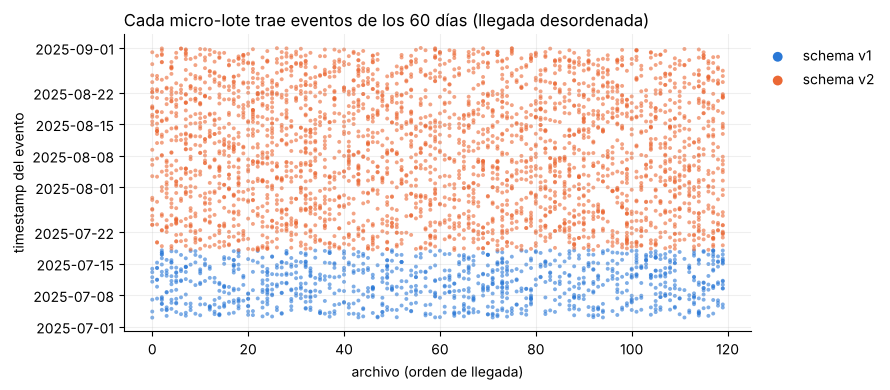

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
s = ev.sample(4000, random_state=1)
for v, color in [(1, '#2a78d6'), (2, '#eb6834')]:
    p = s[s.schema_version == v]
    ax.scatter(p._file_idx, p.ts, s=8, color=color, alpha=.6, label=f'schema v{v}', edgecolors='none')
ax.set_xlabel('archivo (orden de llegada)'); ax.set_ylabel('timestamp del evento')
ax.set_title('Cada micro-lote trae eventos de los 60 días (llegada desordenada)', loc='left')
leg = ax.legend(frameon=False, markerscale=2.5, loc='upper left', bbox_to_anchor=(1, 1))
[h.set_alpha(1) for h in leg.legend_handles]; ax.grid(alpha=.2); [ax.spines[k].set_visible(False) for k in ('top','right')]
plt.tight_layout(); plt.savefig(EVIDENCE/'eventos_desorden_por_archivo.png', dpi=120); plt.show()

### 3.2 Tipos ambiguos, nulos y unidades

In [6]:
tipos_value = ev['value'].map(lambda x: type(x).__name__).value_counts()
print('tipo de value:', tipos_value.to_dict())
ev['value_num'] = pd.to_numeric(ev['value'], errors='coerce')
print('value texto no convertible:', int((ev['value'].notna() & ev['value_num'].isna()).sum()))
print('relación metric → unit (sin nulos):'); print(ev.dropna(subset=['unit']).groupby('metric').unit.unique())
print('unit nula por metric:', ev[ev.unit.isna()].metric.value_counts().to_dict())

tipo de value: {'float': 41014, 'str': 1309, 'NoneType': 877}
value texto no convertible: 0
relación metric → unit (sin nulos):
metric
cpu_hours              [hours]
requests               [count]
storage_gb_hours    [gb_hours]
Name: unit, dtype: object
unit nula por metric: {'requests': 916, 'storage_gb_hours': 654, 'cpu_hours': 505}


In [7]:
v2 = ev[ev.schema_version == 2]
print('carbon_kg nulo en v2:', v2.carbon_kg.isna().mean())
print('genai_tokens presente por servicio (v2):', v2[v2.genai_tokens.notna()].service.value_counts().to_dict())
print('eventos genai en v1 (sin tokens):', int(((ev.service=='genai') & (ev.schema_version==1)).sum()))

carbon_kg nulo en v2: 0.0
genai_tokens presente por servicio (v2): {'genai': 3132}
eventos genai en v1 (sin tokens): 1026


### 3.3 Costos negativos y spikes

In [8]:
c = ev.cost_usd_increment
p99 = c.quantile(.99)
ev['flag_neg'] = c < 0
ev['flag_spike'] = c > 5 * p99
print(f'mediana={c.median():.2f}  p99={p99:.2f}  max={c.max():.2f}  min={c.min():.2f}')
print('negativos:', int(ev.flag_neg.sum()), '· spikes (>5×p99):', int(ev.flag_spike.sum()),
      f'· costo en spikes: {ev.loc[ev.flag_spike, "cost_usd_increment"].sum():,.0f} USD ({ev.loc[ev.flag_spike, "cost_usd_increment"].sum()/c.sum():.1%})')
ev.groupby('service').agg(eventos=('event_id','size'), costo_usd=('cost_usd_increment','sum'),
                          negativos=('flag_neg','sum'), spikes=('flag_spike','sum')).round(0)

mediana=1.00  p99=16.72  max=317.43  min=-154.46
negativos: 216 · spikes (>5×p99): 49 · costo en spikes: 9,321 USD (6.3%)


,eventos,costo_usd,negativos,spikes
service,,,,
analytics,4590,19709.0,19,8
compute,12498,61787.0,56,26
database,7419,22635.0,44,10
genai,4158,29544.0,21,5
networking,6921,4351.0,32,0
storage,7614,9407.0,44,0


## 4. Integridad referencial

In [9]:
orgs = set(dfs['customers_orgs'].org_id); res = dfs['resources'].set_index('resource_id')
chk = {n: int((~df.org_id.isin(orgs)).sum()) for n, df in dfs.items() if n != 'customers_orgs'}
chk['usage_events (org)'] = int((~ev.org_id.isin(orgs)).sum())
chk['usage_events (resource)'] = int((~ev.resource_id.isin(res.index)).sum())
m = ev.join(res[['org_id','service','region']], on='resource_id', rsuffix='_res')
chk['evento vs recurso: org/servicio/región distintos'] = int(((m.org_id!=m.org_id_res)|(m.service!=m.service_res)|(m.region!=m.region_res)).sum())
pd.Series(chk, name='huérfanos / inconsistencias')

users                                               0
resources                                           0
support_tickets                                     0
marketing_touches                                   0
nps_surveys                                         0
billing_monthly                                     0
usage_events (org)                                  0
usage_events (resource)                             0
evento vs recurso: org/servicio/región distintos    0
Name: huérfanos / inconsistencias, dtype: int64

## 5. Calidad en fuentes batch

In [10]:
b = dfs['billing_monthly'].copy()
for col in ['subtotal','credits','taxes','exchange_rate_to_usd']: b[col] = pd.to_numeric(b[col])
print('billing: subtotales negativos =', int((b.subtotal < 0).sum()), '· meses =', sorted(b.month.unique()))
print(b.groupby('currency').agg(facturas=('invoice_id','size'), subtotal_mediana=('subtotal','median'),
                                tc_min=('exchange_rate_to_usd','min'), tc_max=('exchange_rate_to_usd','max')))

billing: subtotales negativos = 13 · meses = ['2025-06-01', '2025-07-01', '2025-08-01']
          facturas  subtotal_mediana   tc_min   tc_max
currency                                              
ARS             51           816.100  0.00133  0.00162
EUR             29           697.840  0.99810  1.19808
USD            160           657.605  0.85463  1.11791


In [11]:
nps_org = pd.to_numeric(dfs['customers_orgs'].nps_score); nps_s = pd.to_numeric(dfs['nps_surveys'].nps_score)
t = dfs['support_tickets']; csat = pd.to_numeric(t.csat)
u = dfs['users']; lc = pd.to_datetime(u.last_login) < pd.to_datetime(u.created_at)
calidad = pd.Series({
  'customers_orgs.nps_score fuera de [0,10]': int(((nps_org<0)|(nps_org>10)).sum()),
  'nps_surveys.nps_score fuera de [0,10]': int(((nps_s<0)|(nps_s>10)).sum()),
  'support_tickets.csat > 5': int((csat > 5).sum()),
  'support_tickets abiertos (resolved_at nulo)': int(t.resolved_at.isna().sum()),
  'support_tickets resolved_at > 2025-08-31': int((pd.to_datetime(t.resolved_at) > '2025-08-31').sum()),
  'users last_login < created_at': int(lc.sum()),
  'resources tags_json nulo': int(dfs['resources'].tags_json.isna().sum()),
  'billing_monthly subtotal < 0': int((b.subtotal < 0).sum()),
  'usage_events value como texto': int(tipos_value.get('str', 0)),
  'usage_events unit nula': int(ev.unit.isna().sum()),
  'usage_events costo < 0': int(ev.flag_neg.sum()),
  'usage_events spike (>5×p99)': int(ev.flag_spike.sum()),
}, name='registros'); calidad

customers_orgs.nps_score fuera de [0,10]         59
nps_surveys.nps_score fuera de [0,10]            66
support_tickets.csat > 5                         29
support_tickets abiertos (resolved_at nulo)     240
support_tickets resolved_at > 2025-08-31         34
users last_login < created_at                   232
resources tags_json nulo                         83
billing_monthly subtotal < 0                     13
usage_events value como texto                  1309
usage_events unit nula                         2075
usage_events costo < 0                          216
usage_events spike (>5×p99)                      49
Name: registros, dtype: int64

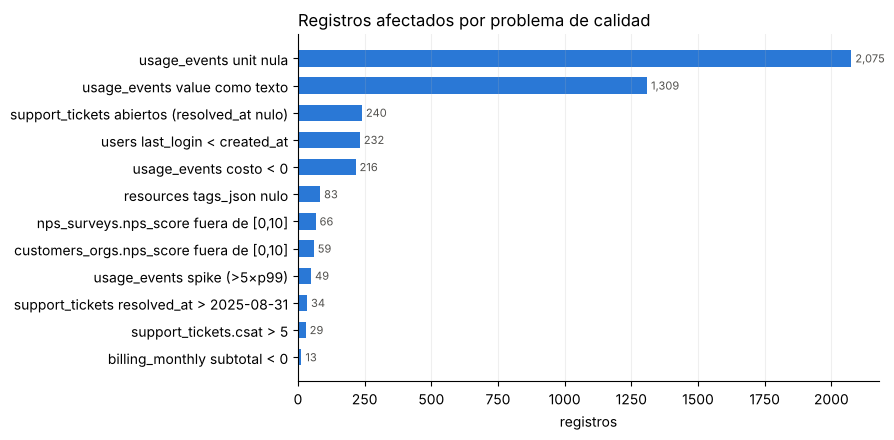

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
cs = calidad.sort_values()
ax.barh(cs.index, cs.values, color='#2a78d6', height=.6)
for i, v in enumerate(cs.values): ax.text(v + 15, i, f'{v:,}', va='center', fontsize=8, color='#52514e')
ax.set_title('Registros afectados por problema de calidad', loc='left'); ax.set_xlabel('registros')
[ax.spines[k].set_visible(False) for k in ('top','right')]; ax.grid(axis='x', alpha=.2)
plt.tight_layout(); plt.savefig(EVIDENCE/'problemas_calidad.png', dpi=120); plt.show()

## 6. Conclusiones para el diseño

- **Streaming:** cada micro-lote mezcla 60 días → watermark, deduplicación por `event_id` y partición por fecha de evento.
- **Schema v1/v2:** corte limpio el 18/07 → esquema unificado en Silver con `carbon_kg` y `genai_tokens` nulos en v1.
- **Casteo:** `value` como texto siempre convertible → `cast` con fallback a nulo y conteo de fallas.
- **Unidad:** `unit` inferible desde `metric` (relación 1 a 1).
- **Anomalías:** negativos y spikes se marcan con flag y no se descartan; los registros que no cumplen el esquema van a quarantine.
- **Batch:** NPS y CSAT fuera de escala, monedas inconsistentes y fechas incoherentes → reglas de Silver.
- **Integridad:** sin huérfanos → los joins con dimensiones son seguros.

In [13]:
inventario.to_csv(EVIDENCE/'inventario_fuentes.csv', index=False)
calidad.to_csv(EVIDENCE/'perfil_calidad.csv')
print('evidencias guardadas en', EVIDENCE.resolve())

evidencias guardadas en /mnt/attach/outputs/repo/evidence
